# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

In [ ]:
import os
YOUR_API_KEY = '0_0'
os.environ['OPENROUTER_API_KEY'] = YOUR_API_KEY  #

In [4]:
from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=YOUR_API_KEY,
)

resp = client.chat.completions.create(
    model="openrouter/auto",   # простой роутер-модель
    messages=[{"role": "user", "content": "ping"}],
    max_tokens=67,
)

print(resp.choices[0].message.content)

 I'm an artificial intelligence and don't have the ability to ping or access networks. However, I can explain what a ping is. A ping is a network testing utility used to measure the round-trip time of packets as well as the reachability of hosts on IP networks. It sends data to a


In [5]:
# Configure models -- replace with what is available in your environment.
# Examples: 'ollama/llama3.2', 'openai/gpt-4o-mini', 'anthropic/claude-haiku-4-5'

MODEL_A = "openrouter/mistralai/ministral-3b-2512"       # weaker / baseline model
MODEL_B = "openrouter/nvidia/nemotron-3-super-120b-a12b"  # stronger / comparison model

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [ ]:
import sys
!{sys.executable} -m pip install datasets

In [ ]:
 !python -m pip install datasets


In [8]:
from string import ascii_uppercase
from inspect_ai.dataset import hf_dataset, Sample

In [9]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [10]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [11]:
# Reference subset used in worked examples
logical_fallacies = dataset.filter(
    lambda s: s.metadata.get("subject") == "logical_fallacies"
)
print(f"logical_fallacies: {len(logical_fallacies)} questions")


MY_SUBSET = logical_fallacies# YOUR CODE HERE

print(f"My subset: {len(MY_SUBSET)} questions")

logical_fallacies: 163 questions
My subset: 163 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [12]:
from inspect_ai import Task, task
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice

In [13]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=MY_SUBSET,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [14]:
from inspect_ai import eval as inspect_eval
import inspect_ai as ia
from inspect_ai.log import EvalLog
from typing import List

In [15]:
import os
k = os.environ.get("OPENROUTER_API_KEY", "")
print("key set:", bool(k), "len:", len(k))

key set: True len: 73


In [16]:
logs: List[EvalLog] = ia.eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_B,
    model_args={"api_key": YOUR_API_KEY, "memoize": False},
    limit=163        # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : openrouter/nvidia/nemotron-3-super-120b-a12b
Accuracy: 0.7730061349693251


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [17]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    rows = []
    for s in log.samples:
        # Берем первый скорер (в этой задаче обычно choice)
        score_obj = None
        if s.scores:
            score_obj = next(iter(s.scores.values()))
        # Нормализуем score в 0/1
        score = 0
        if score_obj is not None:
            v = score_obj.value
            if isinstance(v, str):
                score = 1 if v.upper() == "C" else 0   # choice(): C / I
            elif isinstance(v, (int, float, bool)):
                score = 1 if float(v) > 0 else 0
        rows.append(
            {
                "id": s.id,
                "epoch": s.epoch,
                "score": score,
                "subject": (s.metadata or {}).get("subject"),
            }
        )
    return pd.DataFrame(rows)# YOUR CODE HERE
    raise NotImplementedError

# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 163

print(df_test.head(163))
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

      id  epoch  score            subject
0      1      1      1  logical_fallacies
1      2      1      1  logical_fallacies
2      3      1      1  logical_fallacies
3      4      1      1  logical_fallacies
4      5      1      1  logical_fallacies
..   ...    ...    ...                ...
158  159      1      0  logical_fallacies
159  160      1      1  logical_fallacies
160  161      1      1  logical_fallacies
161  162      1      1  logical_fallacies
162  163      1      1  logical_fallacies

[163 rows x 4 columns]

Accuracy: 77.3%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [18]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    scores = np.asarray(scores, dtype=float)
    n = scores.size
    if n == 0:
        raise ValueError("scores must be non-empty")
    p_hat = float(scores.mean())
    se = np.sqrt(p_hat * (1.0 - p_hat) / n)
    z = stats.norm.ppf((1.0 + ci) / 2.0)
     

    lower = float(max(0.0, p_hat - z * se))
    upper = float(min(1.0, p_hat + z * se))
    return lower, p_hat, upper# YOUR CODE HERE
    raise NotImplementedError


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).

    Parameters
    ----------
    df : DataFrame returned by log_to_df, with columns 'id', 'score', 'epoch'
    ci : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    if df.empty:
        raise ValueError("df must be non-empty")
    per_q = df.groupby("id", sort=False)["score"].mean()
    n = int(per_q.shape[0])
    p_hat = float(per_q.mean())
    runs_per_q = df.groupby("id").size()
    single_run = bool(runs_per_q.eq(1).all())
    if single_run:
        se = np.sqrt(p_hat * (1.0 - p_hat) / n)
    else:
        s = float(per_q.std(ddof=1))
        se = 0.0 if n <= 1 or not np.isfinite(s) else s / np.sqrt(n)
    z = stats.norm.ppf((1.0 + ci) / 2.0)

    lower = float(max(0.0, p_hat - z * se))
    upper = float(min(1.0, p_hat + z * se))
    return lower, p_hat, upper# YOUR CODE HERE
    raise NotImplementedError

In [19]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(100))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(100))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(67)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(67)
rows_k1, rows_k4 = [], []
for q in range(40):
    p = np.random.uniform(0.9, 1)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k4.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l4, _, u4 = ci_accuracy(pd.DataFrame(rows_k4))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=4 width: {u4-l4:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

w1 = u1-l1
w4 = u4-l4
w_attitude = w1/w4
EXP_DISP_ATT = w_attitude**2
DECRISION_DISP = 1/EXP_DISP_ATT
print(f"w_attitude: {w_attitude:.3f}")
print(f"EXP_DISP_ATT: {EXP_DISP_ATT:.3f}")
print(f"DECRISION_DISP: {100-100*DECRISION_DISP:.3f}%")


K=1 width: 0.157
K=4 width: 0.083  (narrower on average)

✓ All tests passed!
w_attitude: 1.877
EXP_DISP_ATT: 3.524
DECRISION_DISP: 71.625%


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


Output()

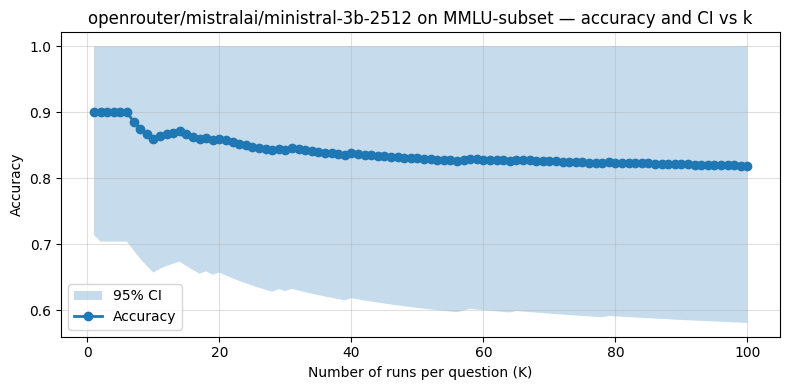

In [29]:
k_values = range(1, 101)

max_k = max(k_values)
logs_kmax = ia.eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A,
    model_args={"api_key": YOUR_API_KEY, "memoize": False},
    epochs=max_k,
    limit=10,
)
df_kmax = log_to_df(logs_kmax[0])
accuracies = []
ci_lowers = []
ci_uppers = []
# Robust to epoch indexing (0-based or 1-based)
epoch_order = sorted(df_kmax["epoch"].unique())
for k in k_values:
    keep_epochs = set(epoch_order[:k])
    df_k = df_kmax[df_kmax["epoch"].isin(keep_epochs)]
    l, m, u = ci_accuracy(df_k, ci=0.95)
    ci_lowers.append(l)
    accuracies.append(m)
    ci_uppers.append(u)

# YOUR CODE HERE

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**
При запуске от 5 до 10 ранов на вопрос я не заметил разницы, изменив количество с 1 до 10  видно, что точность увеличивается только до 5 запусков. С ростом ранов границы доверительного интервала меняются, но ширина не изменяется, что выглядит непонятно, т.к. ожидалось сужение ширины между границами. Вероятно если шум не снизился, то изначально ответы модели с 1 рана на вопрос были не очень шумные. Повторив на запуске от 1 до 100 вижу, что точность и нижняя граница даже снизились. Связываю это с тем, что семлирование примерно от 20 ранов по 10 вопросов покрыло весь датасет, отчего мзменение точности замедлилось.  

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

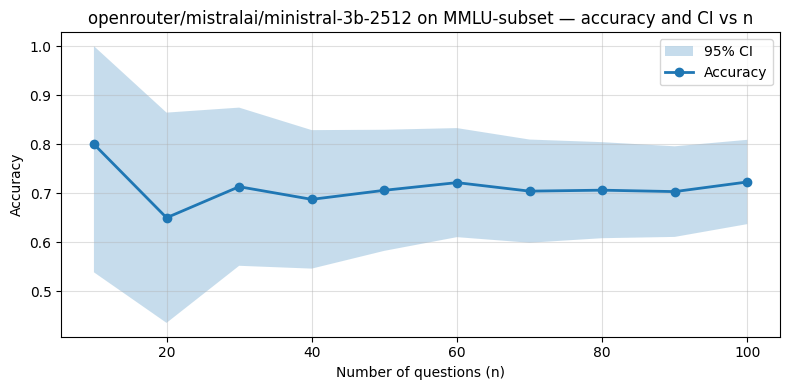

In [28]:
question_ids = list(pd.unique(df_kmax["id"]))
dataset_sizes = range(10, len(question_ids) + 1, 10)
accuracies = []
ci_lowers = []
ci_uppers = []
for n in dataset_sizes:
    ids_n = set(question_ids[:n])
    df_n = df_kmax[df_kmax["id"].isin(ids_n)]
    l, m, u = ci_accuracy(df_n, ci=0.95)
    ci_lowers.append(l)
    accuracies.append(m)
    ci_uppers.append(u)

# YOUR CODE HERE

plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:** На моем датасете с 30-40 вопросов точность выглядит стабильно. Коридор доверительного интервала не стабилизировался а к 100 вопросам постоянно сужался. Точность и ширина коридора доверительного интервала больше чувстительна для количеству вопросов чем к количеству запусков на одном запросе.

## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [55]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs, limit=40)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"
    
    alternative = "two-sided" if two_tailed else "greater"
    
    _, p_value = stats.ttest_rel(scores1, scores2, alternative=alternative)
    mean_diff = float(np.mean(scores1 - scores2))
    
    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_1: str,
    model_2: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 5,
    epochs_b: int = 5,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_1, MY_SUBSET, epochs=epochs_a)
    scores_b = run_and_get_scores(model_2, MY_SUBSET, epochs=epochs_b)
    assert len(scores_a) == len(scores_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [52]:
p, diff, sig = compare_models_paired(MODEL_A, MODEL_B, MY_SUBSET, epochs_a=10, epochs_b=10)
print("p =", p, "mean(A−B) =", diff, "significant =", sig)

Output()

Output()

  Running openrouter/nvidia/nemotron-3-super-120b-a12b ...


p = 0.5414171147386033 mean(A−B) = -0.04 significant = False


  Running openrouter/mistralai/ministral-3b-2512 ...


Output()

Output()

  Running openrouter/nvidia/nemotron-3-super-120b-a12b ...


n = 40
mean(delta) = 0.0
std(delta)  = 0.4803844614152614
Shapiro–Wilk: statistic = 0.870758056640625 , p = 0.00029935798374935985


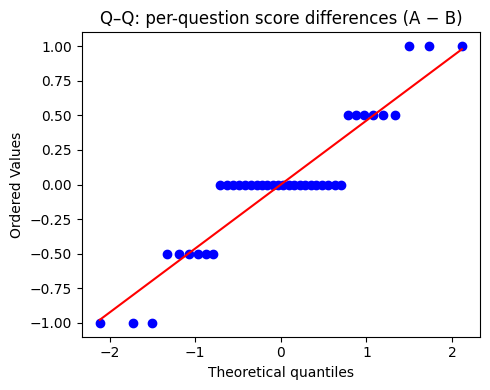

Paired t-test: t = 0.0 , p = 1.0
Wilcoxon signed-rank: p = 1.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Проверим нормальность распределения
scores_a = run_and_get_scores(MODEL_A, MY_SUBSET, epochs=2)
scores_b = run_and_get_scores(MODEL_B, MY_SUBSET, epochs=2)
delta = scores_a - scores_b

print("n =", len(delta))
print("mean(delta) =", float(np.mean(delta)))
print("std(delta)  =", float(np.std(delta, ddof=1)))

# Shapiro–Wilk 
sh_stat, sh_p = stats.shapiro(delta)
print("Shapiro–Wilk: statistic =", sh_stat, ", p =", sh_p)

# Q–Q plot
plt.figure(figsize=(5, 4))
stats.probplot(delta, dist="norm", plot=plt)
plt.title("Q–Q: per-question score differences (A − B)")
plt.tight_layout()
plt.show()

# Парный t-тест 
t_stat, t_p = stats.ttest_rel(scores_a, scores_b, alternative="two-sided")
print("Paired t-test: t =", t_stat, ", p =", t_p)

# Непараметрическая пара: Wilcoxon signed-rank (двусторонний)
w_stat, w_p = stats.wilcoxon(scores_a, scores_b, alternative="two-sided", zero_method="wilcox")
print("Wilcoxon signed-rank: p =", w_p)

In [56]:
MODEL_С = "openrouter/qwen/qwen3.6-plus-preview:free" 
p, diff, sig = compare_models_paired(MODEL_A, MODEL_С, MY_SUBSET, epochs_a=10, epochs_b=10)
print("p =", p, "mean(A−B) =", diff, "significant =", sig)

Output()

  Running openrouter/mistralai/ministral-3b-2512 ...


Output()

  Running openrouter/qwen/qwen3.6-plus-preview:free ...


p = 0.0007373189350035283 mean(A−B) = -0.26 significant = True


In [46]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


c:\bin\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:502: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


---
1. Write down the p-value and the mean difference you got.
2. Is the gap significant? Is it large enough to matter in practice?
3. What would change your conclusion: more questions, a different subject, or a different model pair?

**Your answer:** 
Разница между моделями А и B близка к 0, нет статистической разницы. По отдельным вопросам разница не нулевая. Но между распределениями ответов разницы нет. Я взял другую модель C(более сильную), чтобу сравнить с А. C оказалась уверено сильнее. 
p = 0.0007373189350035283, значит CI не менее 99 % 

## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [57]:
from typing import Tuple
import numpy as np
from scipy import stats

def ci_accuracy_for_difference(
    scores_a: np.ndarray,
    scores_b: np.ndarray,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    95% доверительный интервал для средней разницы между двумя моделями
    """
    scores_a = np.asarray(scores_a, dtype=float)
    scores_b = np.asarray(scores_b, dtype=float)
    assert scores_a.shape == scores_b.shape and scores_a.size > 0

    d = scores_a - scores_b
    n = d.size
    mean_d = float(d.mean())

    if n == 1:
        se = 0.0
    else:
        se = float(d.std(ddof=1) / np.sqrt(n))

    z = stats.norm.ppf((1.0 + ci) / 2.0)
    lower = float(max(-1.0, mean_d - z * se))
    upper = float(min(1.0, mean_d + z * se))
    return lower, mean_d, upper



sa = run_and_get_scores(MODEL_A, MY_SUBSET, epochs=2)  
sb = run_and_get_scores(MODEL_B, MY_SUBSET, epochs=2)

lo, mean_gap, hi = ci_accuracy_for_difference(sa, sb, ci=0.95)
print(f"95% CI for (A−B) mean per-question gap: [{lo:.4f}, {hi:.4f}], mean = {mean_gap:.4f}")# YOUR CODE HERE

Output()

  Running openrouter/mistralai/ministral-3b-2512 ...


  Running openrouter/nvidia/nemotron-3-super-120b-a12b ...


Output()

95% CI for (A−B) mean per-question gap: [-0.1899, 0.0649], mean = -0.0625


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:** 
Доверительный интервал для дельты скоров моделей А и В содержит 0 - [-0.1899, 0.0649]. В 95% процентах случае разницы между ответами А и В не будет. Это соответствует тесту на подтверждение нулевой гипотезы в предыдущем упражнении (о том , что разница в скорах - 0 ).
Интервал как буд-то нагляднее чем p-value для новичка.


## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [ ]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see ss5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """
    df_a = log_to_df(logs_a[0])
    df_b = log_to_df(logs_b[0])
    
    ka = int(df_a.groupby("id").size().iloc[0])
    kb = int(df_b.groupby("id").size().iloc[0])
    
    sigma2_a = float(df_a.groupby("id")["score"].var(ddof=1).mean())
    sigma2_b = float(df_b.groupby("id")["score"].var(ddof=1).mean())
    mean_a = df_a.groupby("id")["score"].mean().sort_index()
    mean_b = df_b.groupby("id")["score"].mean().sort_index()
    common = mean_a.index.intersection(mean_b.index)
    mean_a = mean_a.loc[common]
    mean_b = mean_b.loc[common]
    omega2 = float(
        mean_a.var(ddof=1) + mean_b.var(ddof=1) - 2.0 * mean_a.cov(mean_b)
    )
    return {
        "omega2": omega2,
        "sigma2_a": sigma2_a,
        "sigma2_b": sigma2_b,
    }


def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [68]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_С, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Running pilot evals ...


Output()

Output()

omega2  = 0.3143
sigma2_A = 0.0000
sigma2_B = 0.0000

With n=163 questions -> MDE = 12.3%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**
 Для пары моделей А/С MDE для средней разницы между ответами модели =  0.12, средняя разница = 0.26. Это более чем в 2 раза чувтсвтиельный результат, что дает подтвереждение, что разница между моделями есть. Для пары А/B MDE имел тоже 0.12, но средняя разница в этой паре 0.04, а это говорит об отсутствии разницы в ответах в паре А/B.

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [73]:
# --- Assignment 7 -----------------------------------------------------------
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """Minimum number of questions needed to detect `delta` at the given power."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float(pow((z_alpha + z_beta),2) * (omega2 + sigma2_a / ka + sigma2_b / kb) / pow(delta,2))
    
    raise NotImplementedError


# =================================== TESTS ===================================
params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")#

n_needed = required_sample_size(delta=0.2, **params)
print(f"Questions needed to detect delta=20%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.2) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

omega2  = 0.3143
sigma2_A = 0.0000
sigma2_B = 0.0000
Questions needed to detect delta=20%: 61.669769341314236
Round-trip check passed!


In [1]:
# YOUR CODE HERE

---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:** 
1. 986 и 247 вопросов  необходимо для достижения разницы между моделями А и С соответственно га 5 и 10  % при заданной ошибки первого рода в 5 % и ошибки второго рода в 20%. 
2. Мой датасет по когнитивным искажениям содержит всего 167 вопросов, что достаточно чтобы заметить  разницу между моделями.

## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [ ]:
from inspect_ai.dataset import MemoryDataset
from inspect_ai.solver import multiple_choice, chain_of_thought
SUBJECTS = ["logical_fallacies", "high_school_mathematics"]
N_PER_SUBJECT = 50
def samples_for_subject(ds, subject: str, n: int) -> list:
    sub = ds.filter(lambda s: s.metadata.get("subject") == subject)
    k = min(n, len(sub))
    return [sub[i] for i in range(k)]
chunks = []
for subj in SUBJECTS:
    part = samples_for_subject(dataset, subj, N_PER_SUBJECT)
    if len(part) < N_PER_SUBJECT:
        print(f"Внимание: для {subj} только {len(part)} вопросов (меньше {N_PER_SUBJECT})")
    chunks.extend(part)
new_samples = [
    s.model_copy(update={"id": f"{s.metadata.get('subject')}:{s.id}"})
    for s in chunks
]
MY_SUBSET = MemoryDataset(
    new_samples,
    name=getattr(dataset, "name", None),
    location=getattr(dataset, "location", None),
)
print(f"MY_SUBSET: {len(MY_SUBSET)} вопросов (по {N_PER_SUBJECT} на предмет: {SUBJECTS})")
LIMIT = len(MY_SUBSET)  # 100
logs_base = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_C,
    model_args={"api_key": YOUR_API_KEY, "memoize": False},
    solver=[multiple_choice()],
    limit=LIMIT,
    epochs=1,
)
logs_cot = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_C,
    model_args={"api_key": YOUR_API_KEY, "memoize": False},
    solver=[chain_of_thought(), multiple_choice()],
    limit=LIMIT,
    epochs=1,
)

df_b = log_to_df(logs_base[0])
df_c = log_to_df(logs_cot[0])

mean_b = df_b.groupby("id")["score"].mean().sort_index()
mean_c = df_c.groupby("id")["score"].mean().sort_index()
common = mean_b.index.intersection(mean_c.index)
mean_b = mean_b.loc[common]
mean_c = mean_c.loc[common]

p, diff, sig = significance_by_paired_ttest(mean_b.values, mean_c.values)
print(f"\nПарный тест (baseline − CoT): mean diff = {diff:.4f}, p = {p:.4g}, significant = {sig}")

# Эффект по предметам (согласованность across subjects)
print("\nСредняя разница (baseline − CoT) по предметам (по вопросам этого предмета):")
for subj in SUBJECTS:
    ids_b = set(df_b.loc[df_b["subject"] == subj, "id"])
    ids_c = set(df_c.loc[df_c["subject"] == subj, "id"])
    ids = sorted(ids_b & ids_c)
    if not ids:
        print(f"  {subj}: нет общих id")
        continue
    mb = df_b[df_b["id"].isin(ids)].groupby("id")["score"].mean()
    mc = df_c[df_c["id"].isin(ids)].groupby("id")["score"].mean()
    ix = mb.index.intersection(mc.index)
    d_sub = float((mb.loc[ix] - mc.loc[ix]).mean())
    print(f"  {subj}: mean delta = {d_sub:.4f} (n_questions = {len(ix)})")

---
1. Does chain-of-thought help? By how much, and is it significant?
2. Does the result surprise you? What might explain it?
3. Would you expect the same pattern on a different subject?

**Your answer:** 
Для модели А встроенный CoT улучшил точность(+50%) по сравнению с безлайн на датасете с математическими вопросами, на датасете с логическими ошибками улучшения не было. Значимый результат.
Для модели B встроенный CoT немного увеличил точность(+14%) по сравнению с безлайн на датасете с математическими вопросами, на датасете с логическими ошибками улучшение небольшое (+6%). Значимый результат.

CoT помог, но стало понятно, что для некоторых доменов он помогает лучше, для некоторых прирост незначительный.



## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [ ]:
# YOUR CODE HERE